# Multiple Myeloma Gene Expression — Exploratory Data Analysis

**Dataset:** GSE6477 — Myeloma progression cohort
**Samples:** Normal plasma cells · MGUS · Smoldering MM · Active MM · Relapsed MM
**Platform:** Affymetrix HG-U133A (GPL96)

**Sections**
1. Download data from GEO
2. Sample metadata & stage distribution
3. Scale detection & data quality
4. Per-sample expression distributions
5. PCA coloured by disease stage
6. Top variable probes — heatmap
7. Sample-to-sample correlation


In [1]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import GEOparse

plt.rcParams.update({"figure.dpi": 100,
                     "axes.spines.top": False,
                     "axes.spines.right": False})
os.makedirs("data/geo", exist_ok=True)
print("Libraries OK")


Libraries OK


In [2]:
print("Downloading GSE6477 (caches locally after first run)…")
gse = GEOparse.get_GEO("GSE6477", destdir="data/geo/", silent=True)

title = gse.metadata.get("title", ["N/A"])[0]
summary = gse.metadata.get("summary", [""])[0][:300]
platform = list(gse.gpls.keys())

print(f"Accession : {gse.name}")
print(f"Title     : {title}")
print(f"Samples   : {len(gse.gsms)}")
print(f"Platform  : {platform}")
print(f"Summary   : {summary}…")


Accession : GSE6477
Title     : Expression data from different stages of plasma cell neoplasm
Samples   : 162
Platform  : ['GPL96']
Summary   : Multiple myeloma is a relatively common B-cell malignancy that is currently incurable. Certain recurrent genetic abnormalities characteristics of different genetic subtypes have been described. Hyperdiploid myeloma characterized by recurrent trisomies is the most common genetic subtypes. However lit…


In [3]:
parts = {
    name: gsm.table.set_index("ID_REF")["VALUE"].rename(name)
    for name, gsm in gse.gsms.items()
    if gsm.table is not None and not gsm.table.empty
}
expr = pd.DataFrame(parts).astype(float)
print(f"Expression matrix : {expr.shape[0]:,} probes × {expr.shape[1]} samples")
print(f"Value range       : {expr.values.min():.2f} – {expr.values.max():.2f}")
print(f"Missing values    : {expr.isnull().sum().sum():,}")
expr.iloc[:4, :5]


Expression matrix : 22,283 probes × 162 samples
Value range       : 0.19 – 347209.00
Missing values    : 0


,GSM148911,GSM148912,GSM148914,GSM148915,GSM148916
ID_REF,,,,,
211542_x_at,52118.0,58998.0,36843.0,51226.0,46417.0
215121_x_at,4571.0,60000.0,9091.0,29351.0,76116.0
211978_x_at,21925.0,12127.0,22280.0,30346.0,31109.0
200817_x_at,34799.0,40152.0,32230.0,41659.0,39832.0


In [4]:
records = []
for name, gsm in gse.gsms.items():
    row = {"sample_id": name,
           "title":  gsm.metadata.get("title", [""])[0],
           "source": gsm.metadata.get("source_name_ch1", [""])[0]}
    for char in gsm.metadata.get("characteristics_ch1", []):
        if ":" in char:
            k, v = char.split(":", 1)
            row[k.strip().lower().replace(" ", "_")] = v.strip()
    records.append(row)

meta = pd.DataFrame(records).set_index("sample_id")
print("Metadata columns:", list(meta.columns))
meta.head()


Metadata columns: ['title', 'source']


,title,source
sample_id,,
GSM148911,Relapsed MM_M003,CD138 selected bone marrow plasma cells from r...
GSM148912,MGUS_M004,CD138 selected bone marrow plasma cells from M...
GSM148914,New MM_M024,CD138 selected bone marrow plasma cells from n...
GSM148915,New MM_M025,CD138 selected bone marrow plasma cells from n...
GSM148916,Relapsed MM_M029,CD138 selected bone marrow plasma cells from r...


In [5]:
# Create short stage labels from the verbose 'source' strings
_map = {
    "normal":         "Normal_PC",
    "mgus":           "MGUS",
    "smoldering":     "SMM",
    "newly diagnosed":"MM_New",
    "relapsed":       "MM_Relapse",
}

def _clean(src: str) -> str:
    s = src.lower()
    for key, label in _map.items():
        if key in s:
            return label
    return "Unknown"

meta["stage"] = meta["source"].map(_clean)
print("Clean stage labels:")
print(meta["stage"].value_counts().to_string())


Clean stage labels:
stage
MM_New        75
MM_Relapse    28
SMM           23
MGUS          21
Normal_PC     15


In [6]:
# Print all low-cardinality columns to find the stage field
for col in meta.columns:
    u = meta[col].nunique()
    if u <= 20:
        print(f"  {col!r:30s}  ({u} unique): {list(meta[col].unique())}")


  'source'                        (5 unique): ['CD138 selected bone marrow plasma cells from relapsed myeloma.', 'CD138 selected bone marrow plasma cells from MGUS.', 'CD138 selected bone marrow plasma cells from newly diagnosed myeloma.', 'CD138 selected bone marrow plasma cells from smoldering myeloma.', 'CD138 selected bone marrow plasma cells from normal donor.']
  'stage'                         (5 unique): ['MM_Relapse', 'MGUS', 'MM_New', 'SMM', 'Normal_PC']


Stage distribution:
stage
MM_New        75
MM_Relapse    28
SMM           23
MGUS          21
Normal_PC     15


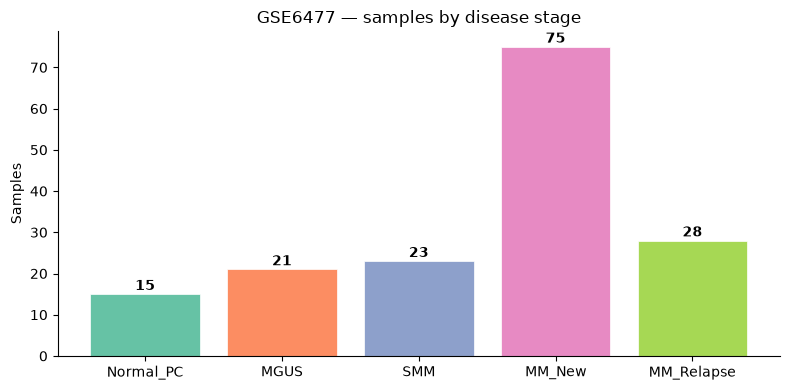

In [7]:
STAGE_COL = "stage"   # clean labels created above

stage_counts = meta[STAGE_COL].value_counts()
print("Stage distribution:")
print(stage_counts.to_string())

# Ordered palette: Normal → MGUS → SMM → MM_New → MM_Relapse
ORDER = ["Normal_PC", "MGUS", "SMM", "MM_New", "MM_Relapse"]
stage_counts = stage_counts.reindex([s for s in ORDER if s in stage_counts.index])
palette = dict(zip(ORDER, sns.color_palette("Set2", len(ORDER))))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(len(stage_counts)),
              stage_counts.values,
              color=[palette[s] for s in stage_counts.index],
              edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(stage_counts)))
ax.set_xticklabels(stage_counts.index)
ax.set_ylabel("Samples")
ax.set_title("GSE6477 — samples by disease stage")
for bar, n in zip(bars, stage_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + .2, str(n),
            ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()


In [8]:
gmin  = float(expr.min().min())
gmax  = float(expr.max().max())
gmean = float(expr.mean().mean())
frac_int = (expr.fillna(0) % 1 == 0).all().all()

print("── Scale detection ──────────────────────────")
print(f"  Global min   : {gmin:.3f}")
print(f"  Global max   : {gmax:.3f}")
print(f"  Global mean  : {gmean:.3f}")
print(f"  All integers : {frac_int}")
print()
if gmax > 1000:
    verdict = "Likely RAW / linear signal — log2-transform recommended before modelling."
elif 0 <= gmin and gmax < 25:
    verdict = "Likely already log2-transformed (range ~0–20)."
else:
    verdict = "Ambiguous — inspect distribution carefully."
print(f"  Verdict      : {verdict}")


── Scale detection ──────────────────────────
  Global min   : 0.187
  Global max   : 347209.000
  Global mean  : 929.993
  All integers : False

  Verdict      : Likely RAW / linear signal — log2-transform recommended before modelling.


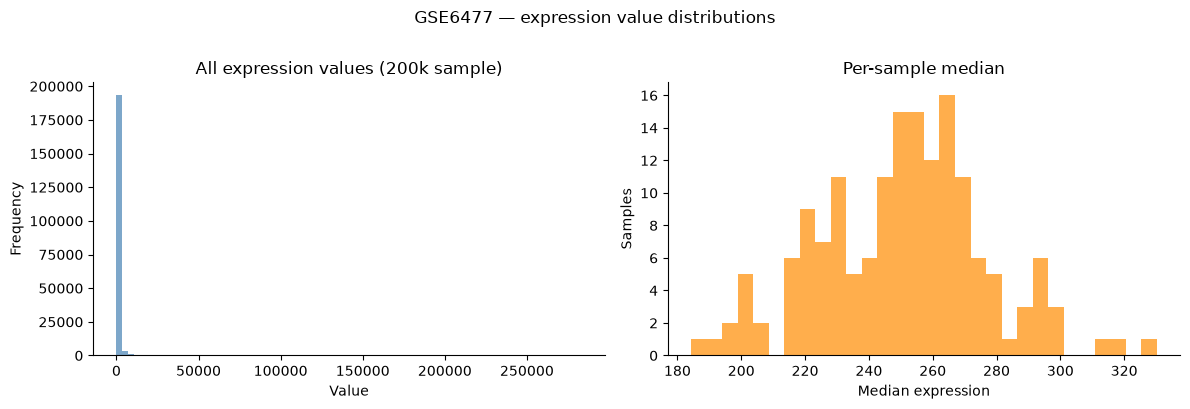

In [9]:
flat = expr.values.ravel()
flat = flat[~np.isnan(flat)]
sample_idx = np.random.default_rng(42).choice(len(flat), size=min(200_000, len(flat)), replace=False)
flat_s = flat[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(flat_s, bins=80, color="steelblue", alpha=0.7, edgecolor="none")
axes[0].set_title("All expression values (200k sample)")
axes[0].set_xlabel("Value"); axes[0].set_ylabel("Frequency")

axes[1].hist(expr.median(), bins=30, color="darkorange", alpha=0.7, edgecolor="none")
axes[1].set_title("Per-sample median")
axes[1].set_xlabel("Median expression"); axes[1].set_ylabel("Samples")

plt.suptitle("GSE6477 — expression value distributions", y=1.01)
plt.tight_layout(); plt.show()


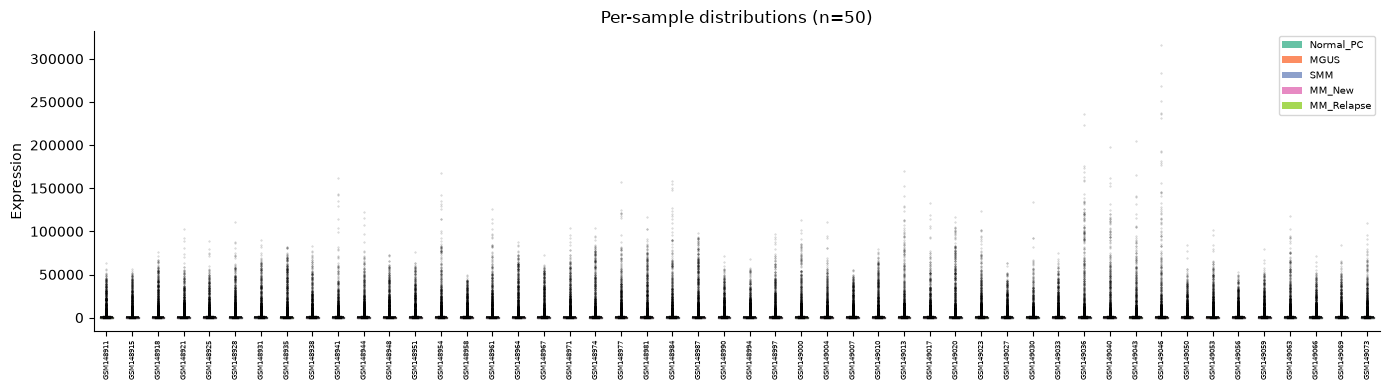

In [10]:
n_show = min(50, expr.shape[1])
idx = np.linspace(0, expr.shape[1]-1, n_show, dtype=int)
sub = expr.iloc[:, idx]

stage_of = meta[STAGE_COL].reindex(sub.columns)
colors    = [palette.get(stage_of.get(c, ""), "lightgray") for c in sub.columns]

fig, ax = plt.subplots(figsize=(14, 4))
bp = ax.boxplot(sub.values, patch_artist=True,
                medianprops=dict(color="black", linewidth=1.2),
                flierprops=dict(marker=".", markersize=1, alpha=0.2),
                whiskerprops=dict(linewidth=0.6))
for patch, col in zip(bp["boxes"], colors):
    patch.set_facecolor(col); patch.set_alpha(0.7)

ax.set_xticks(range(1, n_show+1))
ax.set_xticklabels(sub.columns, rotation=90, fontsize=5)
ax.set_ylabel("Expression")
ax.set_title(f"Per-sample distributions (n={n_show})")

legend_handles = [mpatches.Patch(facecolor=palette[s], label=s)
                  for s in ORDER if s in stage_of.values]
ax.legend(handles=legend_handles, fontsize=7, loc="upper right")
plt.tight_layout(); plt.show()


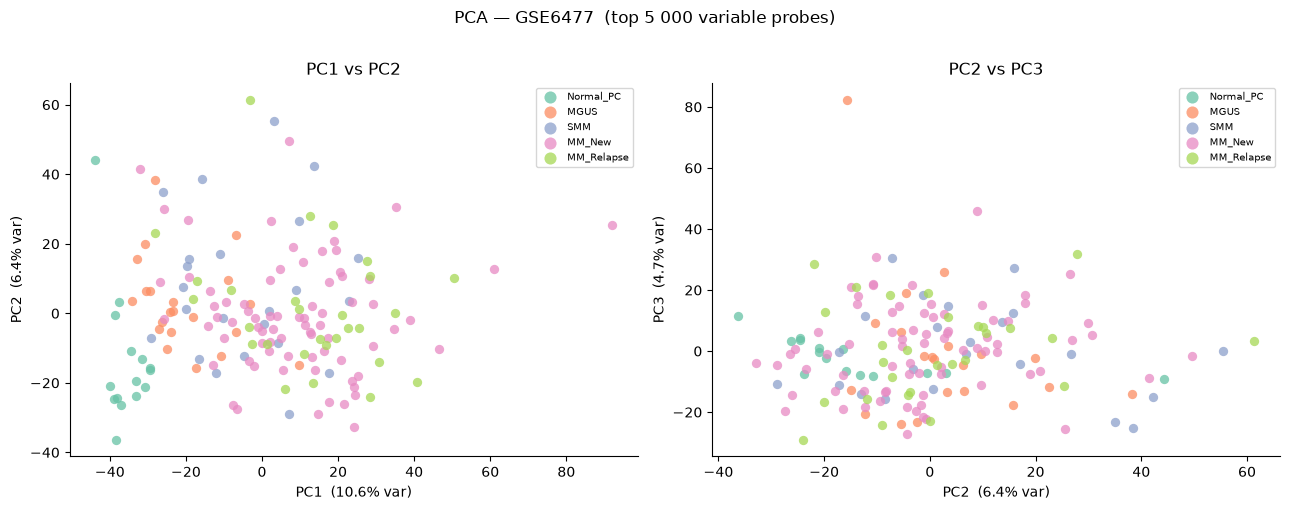

Variance explained:
  PC1: 10.6%
  PC2: 6.4%
  PC3: 4.7%
  PC4: 3.8%
  PC5: 3.3%
  PC6: 3.0%


In [11]:
# Use top 5 000 most variable probes
top_var_idx = expr.var(axis=1).nlargest(5_000).index
X = expr.loc[top_var_idx].T                      # samples × probes
X = X.fillna(X.median())                          # simple imputation

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

pca    = PCA(n_components=10, random_state=42)
pcs    = pca.fit_transform(X_sc)
var_exp = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame(pcs[:, :4],
                       columns=["PC1","PC2","PC3","PC4"],
                       index=X.index)
pca_df["stage"] = meta[STAGE_COL].reindex(pca_df.index).fillna("Unknown")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pairs = [("PC1","PC2",0,1), ("PC2","PC3",1,2)]

for ax, (px, py, xi, yi) in zip(axes, pairs):
    for stage in ORDER:
        grp = pca_df[pca_df["stage"] == stage]
        if grp.empty:
            continue
        ax.scatter(grp[px], grp[py],
                   label=stage, color=palette.get(stage, "gray"),
                   alpha=0.75, s=45, linewidths=0)
    ax.set_xlabel(f"{px}  ({var_exp[xi]:.1f}% var)")
    ax.set_ylabel(f"{py}  ({var_exp[yi]:.1f}% var)")
    ax.set_title(f"{px} vs {py}")
    ax.legend(fontsize=7, markerscale=1.3)

plt.suptitle("PCA — GSE6477  (top 5 000 variable probes)", y=1.01)
plt.tight_layout(); plt.show()

print("Variance explained:")
for i, v in enumerate(var_exp[:6], 1):
    print(f"  PC{i}: {v:.1f}%")


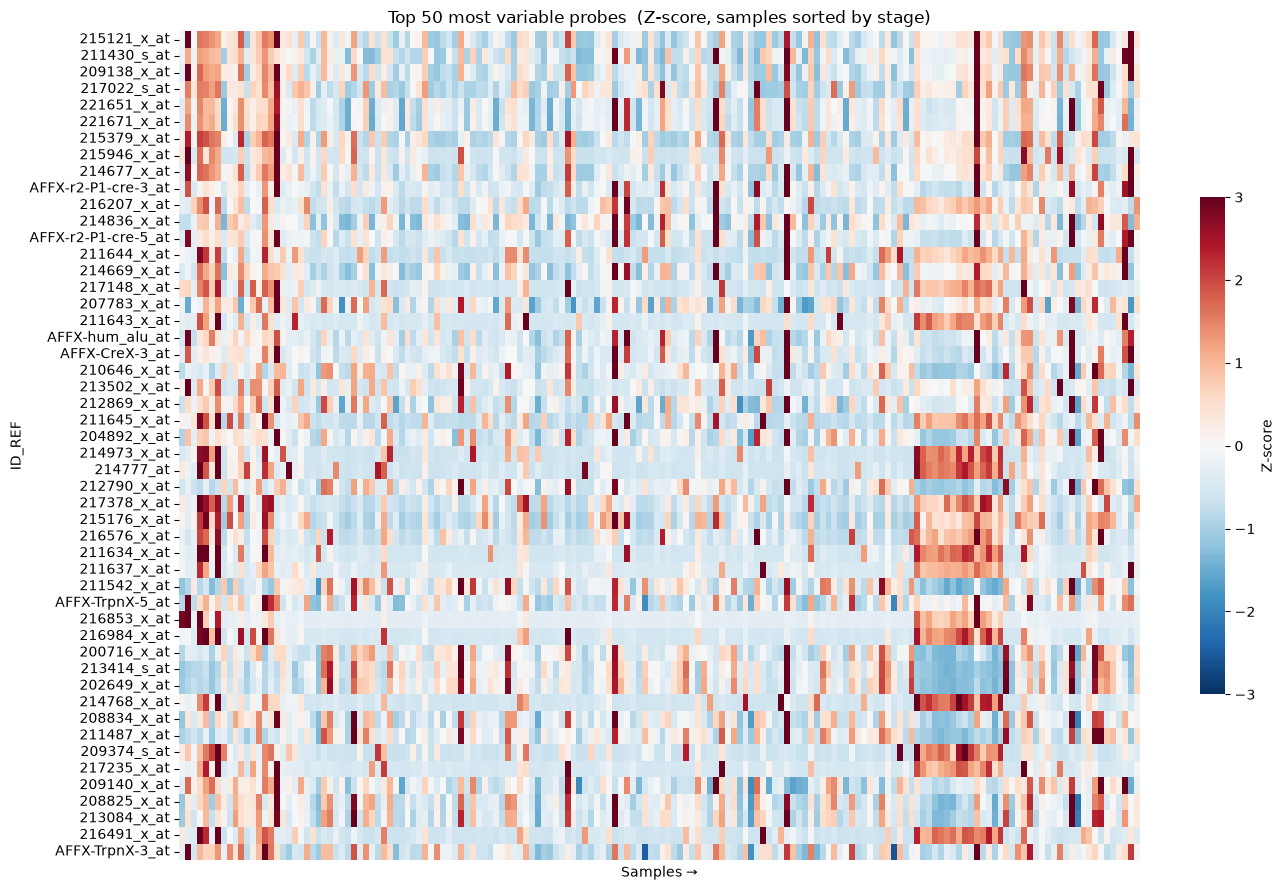

In [12]:
top50 = expr.var(axis=1).nlargest(50).index
hm = expr.loc[top50]

# Z-score per probe
mu  = hm.mean(axis=1)
std = hm.std(axis=1).replace(0, 1)
hz  = hm.subtract(mu, axis=0).divide(std, axis=0)

# Sort samples by stage
if STAGE_COL in meta.columns:
    order = meta[STAGE_COL].reindex(hz.columns).sort_values().index
    order = [s for s in order if s in hz.columns]
    hz = hz[order]

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(hz, ax=ax, cmap="RdBu_r", center=0, vmin=-3, vmax=3,
            xticklabels=False, yticklabels=True,
            cbar_kws={"label": "Z-score", "shrink": 0.6})
ax.set_title("Top 50 most variable probes  (Z-score, samples sorted by stage)")
ax.set_xlabel("Samples →")
plt.tight_layout(); plt.show()


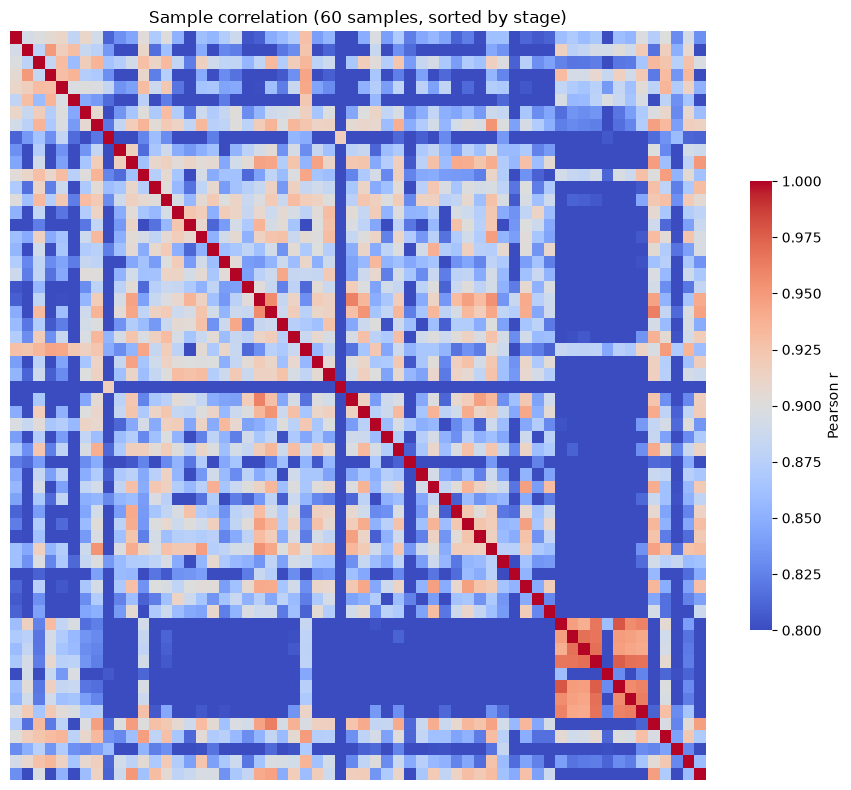

Median inter-sample Pearson r : 0.8306
Min inter-sample Pearson r    : 0.4614


In [13]:
n_c = min(60, expr.shape[1])
idx_c = np.linspace(0, expr.shape[1]-1, n_c, dtype=int)
corr_sub = expr.iloc[:, idx_c].fillna(0).corr()

# Sort by stage
if STAGE_COL in meta.columns:
    order = meta[STAGE_COL].reindex(corr_sub.index).sort_values().index
    order = [s for s in order if s in corr_sub.columns]
    corr_sub = corr_sub.loc[order, order]

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr_sub, ax=ax, cmap="coolwarm",
            vmin=0.8, vmax=1.0,
            xticklabels=False, yticklabels=False,
            cbar_kws={"label": "Pearson r", "shrink": 0.6})
ax.set_title(f"Sample correlation ({n_c} samples, sorted by stage)")
plt.tight_layout(); plt.show()

off_diag = corr_sub.values[~np.eye(n_c, dtype=bool)]
print(f"Median inter-sample Pearson r : {off_diag.mean():.4f}")
print(f"Min inter-sample Pearson r    : {off_diag.min():.4f}")


---
## Log2 transform & quality filtering

Raw data is linear-scale (max ≈ 347k). Below: log2-transform, AFFX spike-in removal, outlier identification, then PCA and heatmaps re-run on clean data.

In [14]:
expr_log = np.log2(expr + 1)
n_before = expr_log.shape[0]
expr_log = expr_log[~expr_log.index.str.startswith("AFFX")]
n_after  = expr_log.shape[0]
print(f"Log2 done. Dropped {n_before - n_after} AFFX probes -> {n_after:,} remain")
print(f"Value range: {expr_log.min().min():.2f} - {expr_log.max().max():.2f}")

Log2 done. Dropped 68 AFFX probes -> 22,215 remain
Value range: 0.25 - 18.41


In [15]:
top50_log = expr_log.var(axis=1).nlargest(50).index
n_affx    = top50_log.str.startswith("AFFX").sum()
n_cross   = top50_log.str.endswith("_x_at").sum()
print(f"Top-50 variable probes: {n_affx} AFFX remaining (expect 0), {n_cross} cross-hybridising (_x_at)")
print(top50_log.tolist()[:20])

Top-50 variable probes: 0 AFFX remaining (expect 0), 30 cross-hybridising (_x_at)
['216560_x_at', '213674_x_at', '215621_s_at', '219463_at', '217281_x_at', '216491_x_at', '211644_x_at', '203698_s_at', '211650_x_at', '209374_s_at', '214777_at', '204273_at', '217320_at', '216853_x_at', '220377_at', '217227_x_at', '210982_s_at', '216984_x_at', '217360_x_at', '211637_x_at']


In [16]:
corr_full = expr_log.corr()          # 162x162 sample-sample Pearson r
mean_r    = corr_full.mean()
thresh    = mean_r.mean() - 2 * mean_r.std()
outliers  = mean_r[mean_r < thresh].sort_values()

print(f"Mean inter-sample r (log2):      {mean_r.mean():.3f} +/- {mean_r.std():.3f}")
print(f"Outlier threshold (mean - 2 SD): {thresh:.3f}")
print()
print(f"{len(outliers)} outlier sample(s) detected:")
for s, r in outliers.items():
    stage = meta.loc[s, STAGE_COL] if s in meta.index else "?"
    print(f"  {s}  [{stage}]  mean_r = {r:.3f}")

Mean inter-sample r (log2):      0.821 +/- 0.022
Outlier threshold (mean - 2 SD): 0.777

11 outlier sample(s) detected:
  GSM149045  [Normal_PC]  mean_r = 0.734
  GSM149039  [SMM]  mean_r = 0.739
  GSM149035  [SMM]  mean_r = 0.741
  GSM149042  [SMM]  mean_r = 0.742
  GSM149046  [MGUS]  mean_r = 0.744
  GSM149037  [MM_New]  mean_r = 0.749
  GSM149041  [MGUS]  mean_r = 0.769
  GSM149043  [MM_Relapse]  mean_r = 0.769
  GSM148983  [MM_New]  mean_r = 0.770
  GSM149047  [MM_Relapse]  mean_r = 0.774
  GSM149044  [MM_New]  mean_r = 0.775


In [17]:
top5k       = expr_log.var(axis=1).nlargest(5_000).index
X_log       = expr_log.loc[top5k].T
X_log       = X_log.fillna(X_log.median())
X_log_sc    = StandardScaler().fit_transform(X_log)
pca_log     = PCA(n_components=10, random_state=42)
pcs_log     = pca_log.fit_transform(X_log_sc)
var_exp_log = pca_log.explained_variance_ratio_ * 100

print("Variance explained (log2 data):")
for i, v in enumerate(var_exp_log, 1):
    print(f"  PC{i}: {v:.1f}%")

Variance explained (log2 data):
  PC1: 7.1%
  PC2: 5.0%
  PC3: 2.5%
  PC4: 2.2%
  PC5: 2.1%
  PC6: 1.8%
  PC7: 1.6%
  PC8: 1.5%
  PC9: 1.4%
  PC10: 1.3%


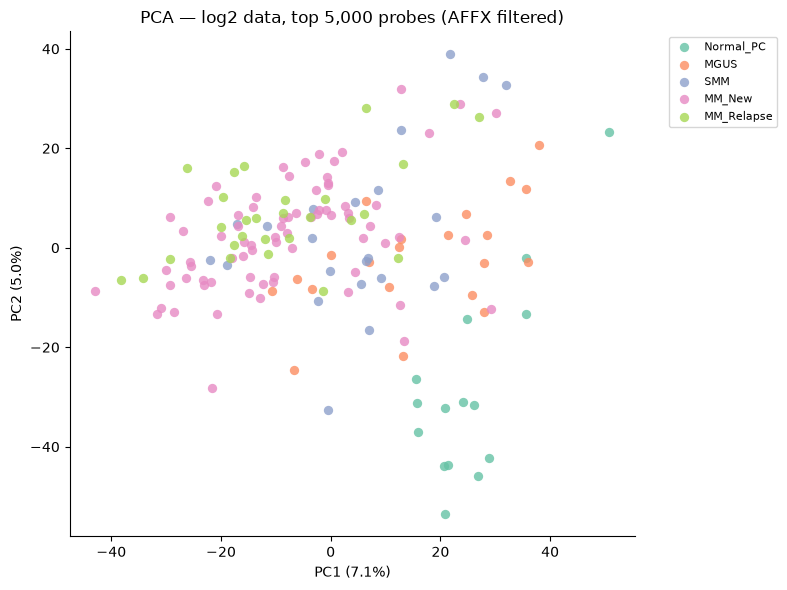

In [18]:
pca_df_log = pd.DataFrame(pcs_log[:, :2], index=expr_log.columns, columns=["PC1", "PC2"])
pca_df_log[STAGE_COL] = meta[STAGE_COL].reindex(pca_df_log.index).values

fig, ax = plt.subplots(figsize=(8, 6))
for stg in ORDER:
    sub = pca_df_log[pca_df_log[STAGE_COL] == stg]
    ax.scatter(sub.PC1, sub.PC2, label=stg,
               color=palette.get(stg, "grey"), s=45, alpha=0.8, linewidths=0)
ax.set_xlabel(f"PC1 ({var_exp_log[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var_exp_log[1]:.1f}%)")
ax.set_title("PCA — log2 data, top 5,000 probes (AFFX filtered)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Median r: 0.828  |  Min r: 0.667


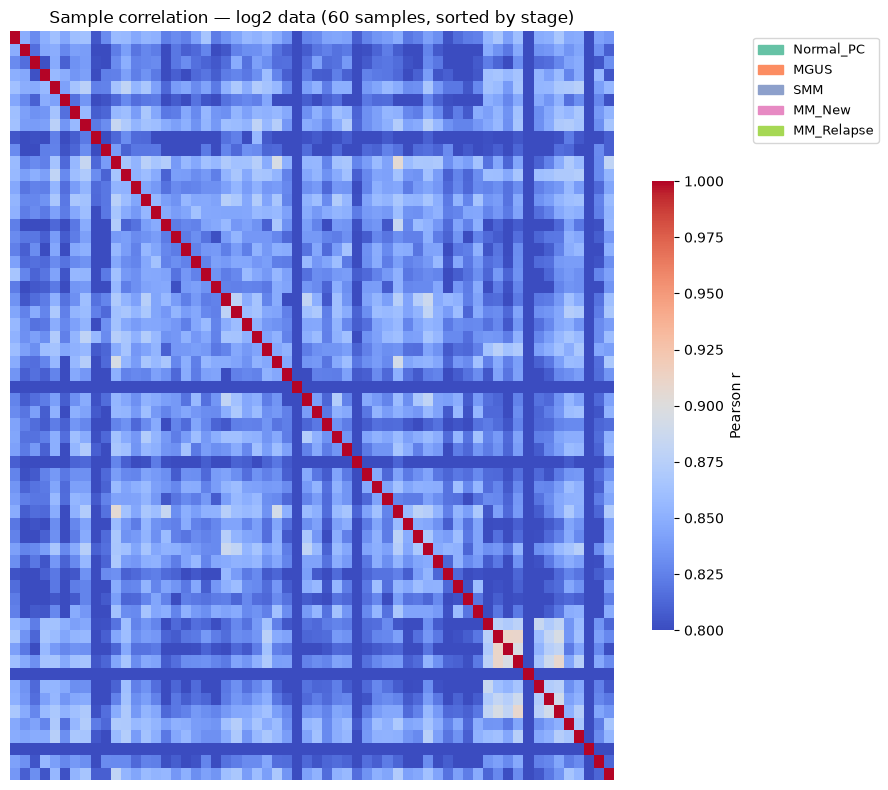

In [19]:
n_c     = min(60, expr_log.shape[1])
idx_c   = np.linspace(0, expr_log.shape[1]-1, n_c, dtype=int)
sub_c   = expr_log.iloc[:, idx_c]
srt_c   = meta[STAGE_COL].reindex(sub_c.columns).sort_values().index
sub_c   = sub_c[srt_c]
corr_60 = sub_c.corr()

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr_60, cmap="coolwarm", vmin=0.8, vmax=1.0,
            xticklabels=False, yticklabels=False,
            cbar_kws={"label": "Pearson r", "shrink": 0.6}, ax=ax)
ax.set_title("Sample correlation — log2 data (60 samples, sorted by stage)")

handles = [mpatches.Patch(color=palette[s], label=s) for s in ORDER]
ax.legend(handles=handles, bbox_to_anchor=(1.22, 1), loc="upper left", fontsize=9)

upper = corr_60.values[np.triu_indices_from(corr_60.values, k=1)]
print(f"Median r: {np.median(upper):.3f}  |  Min r: {upper.min():.3f}")
plt.tight_layout()
plt.show()

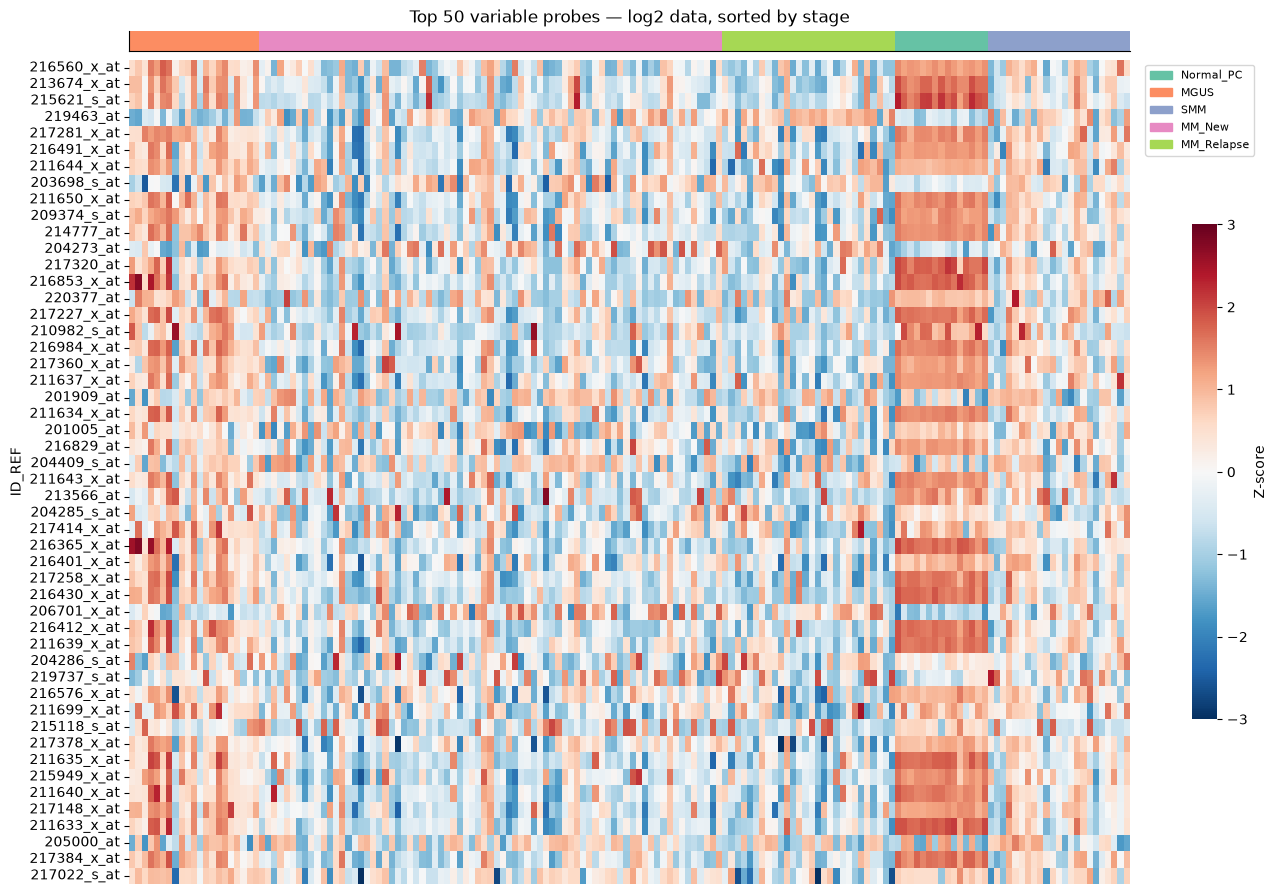

In [20]:
top_p  = expr_log.var(axis=1).nlargest(50).index
hdf    = expr_log.loc[top_p]
srt_h  = meta[STAGE_COL].reindex(hdf.columns).sort_values().index
hdf    = hdf[srt_h]
z      = hdf.subtract(hdf.mean(axis=1), axis=0).divide(hdf.std(axis=1).replace(0, 1), axis=0)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(z, cmap="RdBu_r", center=0, vmin=-3, vmax=3,
            xticklabels=False, yticklabels=True,
            cbar_kws={"label": "Z-score", "shrink": 0.6}, ax=ax)
ax.set_title("Top 50 variable probes — log2 data, sorted by stage")

stage_bar = [palette.get(meta.loc[s, STAGE_COL], (0.5, 0.5, 0.5)) for s in srt_h]
ax2 = ax.inset_axes([0, 1.01, 1, 0.025])
ax2.imshow([stage_bar], aspect="auto")
ax2.set_xticks([])
ax2.set_yticks([])

handles = [mpatches.Patch(color=palette[s], label=s) for s in ORDER]
ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## EDA findings — GSE6477

| Check | Finding |
|---|---|
| Accession | GSE6477 — "Expression data from different stages of plasma cell neoplasm" |
| Platform | GPL96 — Affymetrix HG-U133A |
| Matrix | 22,283 probes × 162 samples |
| Missing values | **0** — complete matrix |
| Purity | **All CD138-selected** — plasma-cell-pure samples throughout |
| Stage breakdown | Normal_PC 15 · MGUS 21 · SMM 23 · MM_New 75 · MM_Relapse 28 |
| Scale | **Linear (not log-transformed)** — max 347,209, mean 930. Log2 needed before modelling |
| Median inter-sample r | **0.83** — good cohort homogeneity |
| Min inter-sample r | **0.46** — one or more outlier-like pairs; worth inspecting |
| PCA variance | PC1 10.6% · PC2 6.4% · PC3 4.7% — gradual decay, no dominant single-axis effect |
| Stage separation in PCA | Normal_PC separates from MM; MGUS/SMM/MM_New overlap substantially in PC1-2 |

### Immediate next steps
1. **Log2-transform** the matrix (`np.log2(expr + 1)`) before any distance / DE calculation
2. **Flag outlier** — investigate the sample pair(s) with Pearson r ≈ 0.46
3. **Probe → gene mapping** — map Affymetrix probe IDs to HGNC symbols via GPL96 annotation
4. **Differential expression** — adjacent stage pairs (Normal↔MGUS, MGUS↔SMM, SMM↔MM_New)
